# Tech Challenge Fase 3 — Machine Learning Engineering
## Previsão de Atrasos de Voos nos EUA

**FIAP PosTech — Pós-Graduação em Data Science**

Este notebook implementa um pipeline completo de Data Science com Machine Learning supervisionado e não supervisionado para analisar e prever atrasos de voos nos EUA utilizando o dataset de 2015.

---
## PASSO 1 — Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Pre-processamento
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

# Sklearn - Modelos supervisionados
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet, SGDClassifier, SGDRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Sklearn - Metricas
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    precision_score, recall_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.model_selection import learning_curve

# Sklearn - Modelos nao supervisionados
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

# Visualizacao interativa
import plotly.express as px
import plotly.graph_objects as go

# Configuracoes globais
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
RANDOM_STATE = 42

print("Imports concluidos!")

Imports concluidos!


---
## PASSO 2 — Carga dos Dados

In [2]:
# Caminho dos arquivos de dados
DATA_PATH = r'C:\Users\silva\workspace\FIAP\arquivos-fase-3'

df = pd.read_csv(f'{DATA_PATH}/flights.csv', low_memory=False)
airlines = pd.read_csv(f'{DATA_PATH}/airlines.csv')
airports = pd.read_csv(f'{DATA_PATH}/airports.csv')

print(f"flights: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"airlines: {airlines.shape}")
print(f"airports: {airports.shape}")

# Mostrar primeiras linhas
df.head()

flights: 5,819,079 linhas x 31 colunas
airlines: (14, 2)
airports: (322, 7)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Amostragem de 1 milhao de voos para melhor representatividade
# O dataset completo tem ~5.8 milhoes de linhas

df = df.sample(n=1_000_000, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Amostra: {df.shape}")

Amostra: (1000000, 31)


---
## PASSO 3 — EDA (Exploração dos Dados)

### 3.1 — Visão geral e estatísticas descritivas

In [4]:
# Info geral
print("=== INFORMACOES GERAIS ===")
df.info()

print("\n=== ESTATISTICAS DESCRITIVAS ===")
df.describe().T

=== INFORMACOES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 31 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   YEAR                 1000000 non-null  int64  
 1   MONTH                1000000 non-null  int64  
 2   DAY                  1000000 non-null  int64  
 3   DAY_OF_WEEK          1000000 non-null  int64  
 4   AIRLINE              1000000 non-null  object 
 5   FLIGHT_NUMBER        1000000 non-null  int64  
 6   TAIL_NUMBER          997527 non-null   object 
 7   ORIGIN_AIRPORT       1000000 non-null  object 
 8   DESTINATION_AIRPORT  1000000 non-null  object 
 9   SCHEDULED_DEPARTURE  1000000 non-null  int64  
 10  DEPARTURE_TIME       985319 non-null   float64
 11  DEPARTURE_DELAY      985319 non-null   float64
 12  TAXI_OUT             984808 non-null   float64
 13  WHEELS_OFF           984808 non-null   float64
 14  SCHEDULED_TIME       100

,count,mean,std,min,25%,50%,75%,max
YEAR,1000000.0,2015.000000,0.000000,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,1000000.0,6.520993,3.404754,1.0,4.0,7.0,9.0,12.0
DAY,1000000.0,15.706158,8.783773,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,1000000.0,3.924296,1.988860,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,1000000.0,2171.356441,1756.398729,1.0,730.0,1689.0,3225.0,7438.0
SCHEDULED_DEPARTURE,1000000.0,1329.527098,483.618301,1.0,917.0,1325.0,1730.0,2359.0
DEPARTURE_TIME,985319.0,1335.226597,496.279667,1.0,921.0,1330.0,1739.0,2400.0
DEPARTURE_DELAY,985319.0,9.370586,37.179661,-47.0,-5.0,-2.0,7.0,1670.0
TAXI_OUT,984808.0,16.075959,8.925907,1.0,11.0,14.0,19.0,225.0
WHEELS_OFF,984808.0,1357.208352,497.884668,1.0,935.0,1343.0,1754.0,2400.0


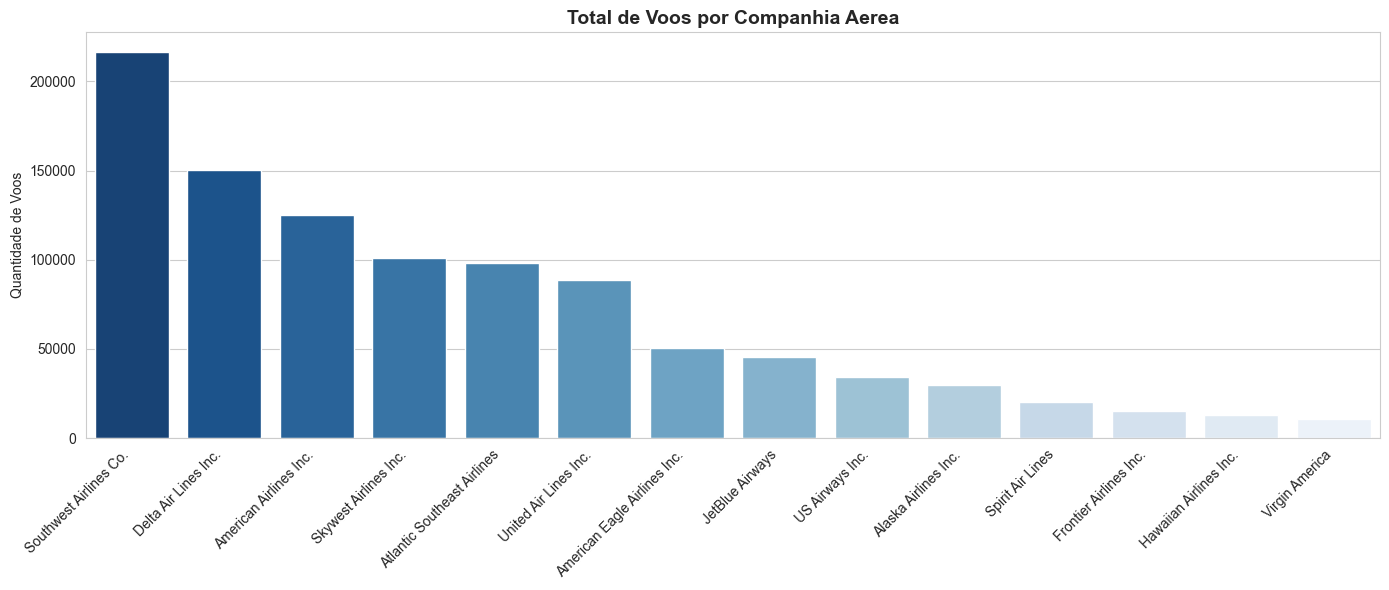

In [5]:
# Distribuicao dos voos por companhia (com nome completo via merge)
voos_por_companhia = df['AIRLINE'].value_counts().reset_index()
voos_por_companhia.columns = ['IATA_CODE', 'total_voos']
voos_por_companhia = voos_por_companhia.merge(airlines, on='IATA_CODE')

plt.figure(figsize=(14, 6))
sns.barplot(data=voos_por_companhia, x='AIRLINE', y='total_voos', palette='Blues_r')
plt.xticks(rotation=45, ha='right')
plt.title('Total de Voos por Companhia Aerea', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Quantidade de Voos')
plt.tight_layout()
plt.show()

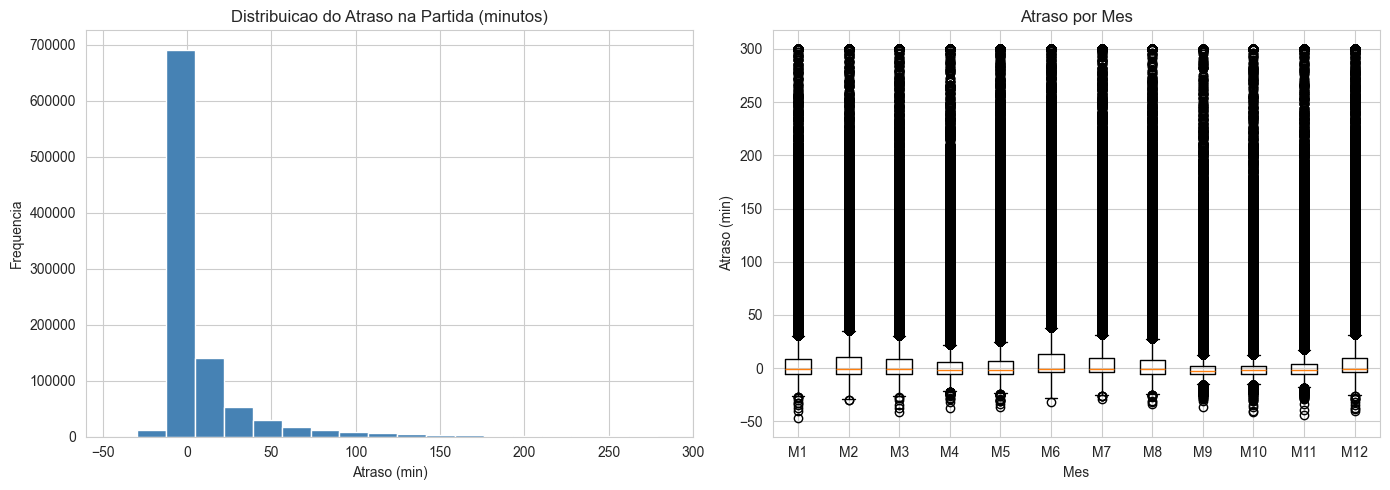

In [6]:
# Distribuicao dos atrasos na partida
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma geral
axes[0].hist(df['DEPARTURE_DELAY'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_xlim(-60, 300)
axes[0].set_title('Distribuicao do Atraso na Partida (minutos)')
axes[0].set_xlabel('Atraso (min)')
axes[0].set_ylabel('Frequencia')

# Box plot por mes
df_clean = df[df['DEPARTURE_DELAY'].notna()].copy()
axes[1].boxplot(
    [df_clean[df_clean['MONTH'] == m]['DEPARTURE_DELAY'].clip(-60, 300) for m in range(1, 13)],
    labels=[f'M{m}' for m in range(1, 13)]
)
axes[1].set_title('Atraso por Mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Atraso (min)')

plt.tight_layout()
plt.show()

### 3.2 — Análise de Valores Ausentes

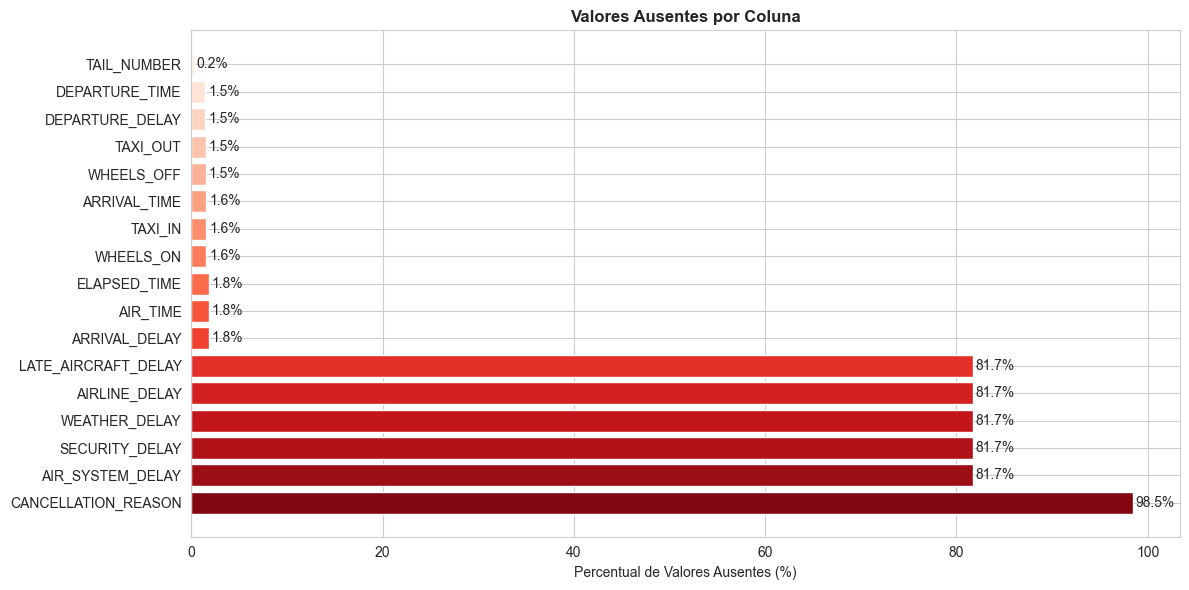

                     Ausentes  Percentual
CANCELLATION_REASON    984650     98.4650
AIR_SYSTEM_DELAY       817494     81.7494
SECURITY_DELAY         817494     81.7494
WEATHER_DELAY          817494     81.7494
AIRLINE_DELAY          817494     81.7494
LATE_AIRCRAFT_DELAY    817494     81.7494
ARRIVAL_DELAY           17960      1.7960
AIR_TIME                17960      1.7960
ELAPSED_TIME            17960      1.7960
WHEELS_ON               15805      1.5805
TAXI_IN                 15805      1.5805
ARRIVAL_TIME            15805      1.5805
WHEELS_OFF              15192      1.5192
TAXI_OUT                15192      1.5192
DEPARTURE_DELAY         14681      1.4681
DEPARTURE_TIME          14681      1.4681
TAIL_NUMBER              2473      0.2473


In [7]:
# Calcular e visualizar valores ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Ausentes': missing, 'Percentual': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0].sort_values('Percentual', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.barh(missing_df.index, missing_df['Percentual'],
                color=sns.color_palette('Reds_r', len(missing_df)))
for bar, pct in zip(bars, missing_df['Percentual']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center')
plt.xlabel('Percentual de Valores Ausentes (%)')
plt.title('Valores Ausentes por Coluna', fontweight='bold')
plt.tight_layout()
plt.show()

print(missing_df)

### 3.3 — Tratamento de Valores Ausentes

In [8]:
print(f"Shape original: {df.shape}")

# Remover voos cancelados (CANCELLED=1) para analise de atraso
df = df[df['CANCELLED'] == 0].copy()
print(f"Apos remover cancelados: {df.shape}")

# Remover voos desviados (DIVERTED=1)
df = df[df['DIVERTED'] == 0].copy()
print(f"Apos remover desviados: {df.shape}")

# Colunas de causa de atraso: NaN significa ausencia de atraso por aquela causa -> preencher com 0
cols_atraso = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
               'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
df[cols_atraso] = df[cols_atraso].fillna(0)

# DEPARTURE_DELAY e ARRIVAL_DELAY: preencher NaN com mediana
df['DEPARTURE_DELAY'] = df['DEPARTURE_DELAY'].fillna(df['DEPARTURE_DELAY'].median())
df['ARRIVAL_DELAY'] = df['ARRIVAL_DELAY'].fillna(df['ARRIVAL_DELAY'].median())

# Remover colunas com muitos NaN que nao serao usadas
df.drop(columns=['CANCELLATION_REASON', 'TAIL_NUMBER'], inplace=True, errors='ignore')

# Verificar resultado
print(f"\nShape final: {df.shape}")
print(f"Valores ausentes restantes:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape original: (1000000, 31)
Apos remover cancelados: (984650, 31)
Apos remover desviados: (982040, 31)

Shape final: (982040, 29)
Valores ausentes restantes:
Series([], dtype: int64)


### 3.4 — Visualizações com Insights

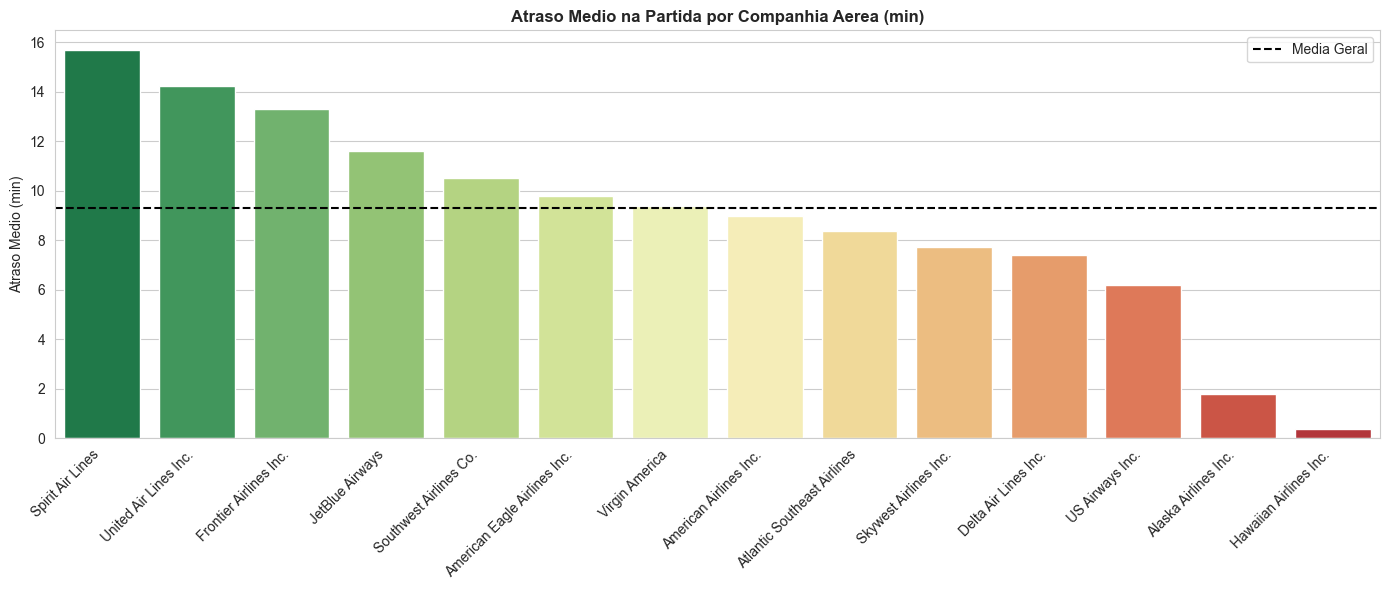

In [9]:
# Atraso medio por companhia
atraso_por_cia = df.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).reset_index()
atraso_por_cia = atraso_por_cia.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE')

plt.figure(figsize=(14, 6))
sns.barplot(data=atraso_por_cia, x='AIRLINE_y', y='DEPARTURE_DELAY', palette='RdYlGn_r')
plt.xticks(rotation=45, ha='right')
plt.title('Atraso Medio na Partida por Companhia Aerea (min)', fontweight='bold')
plt.xlabel('')
plt.ylabel('Atraso Medio (min)')
plt.axhline(y=df['DEPARTURE_DELAY'].mean(), color='black', linestyle='--', label='Media Geral')
plt.legend()
plt.tight_layout()
plt.show()

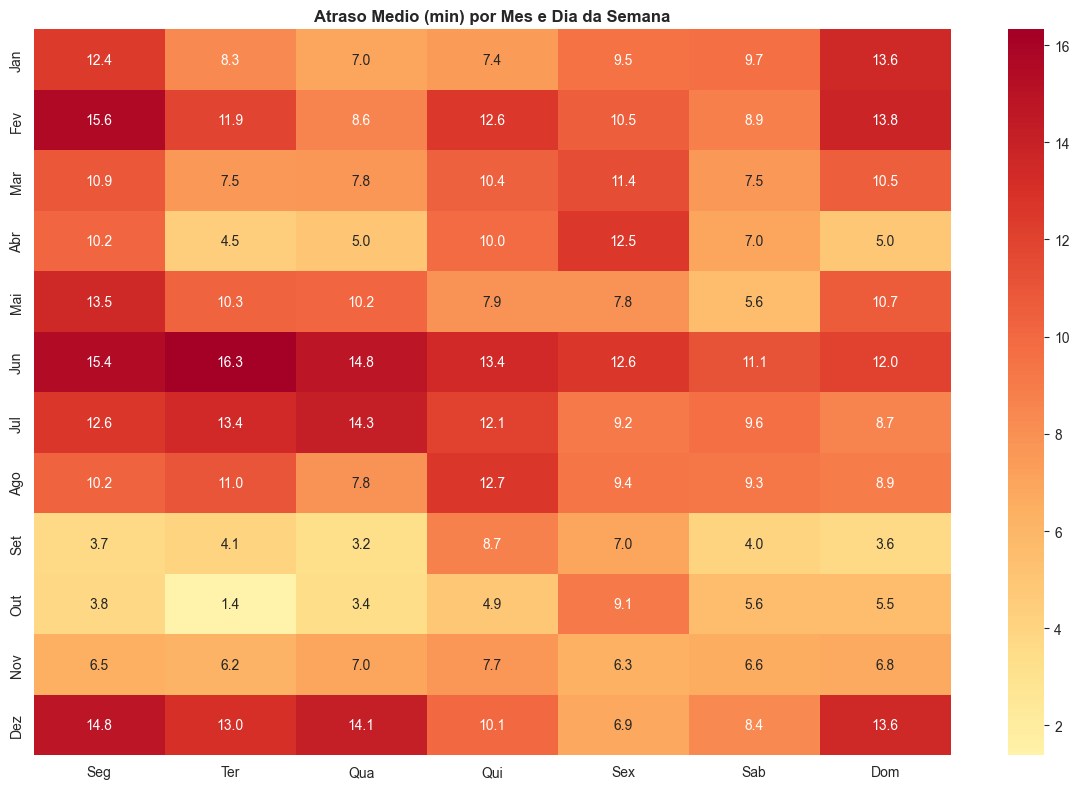

In [10]:
# Atraso medio por dia da semana e por mes (heatmap)
pivot = df.groupby(['MONTH', 'DAY_OF_WEEK'])['DEPARTURE_DELAY'].mean().unstack()
pivot.index = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
pivot.columns = ['Seg','Ter','Qua','Qui','Sex','Sab','Dom']

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0)
plt.title('Atraso Medio (min) por Mes e Dia da Semana', fontweight='bold')
plt.tight_layout()
plt.show()

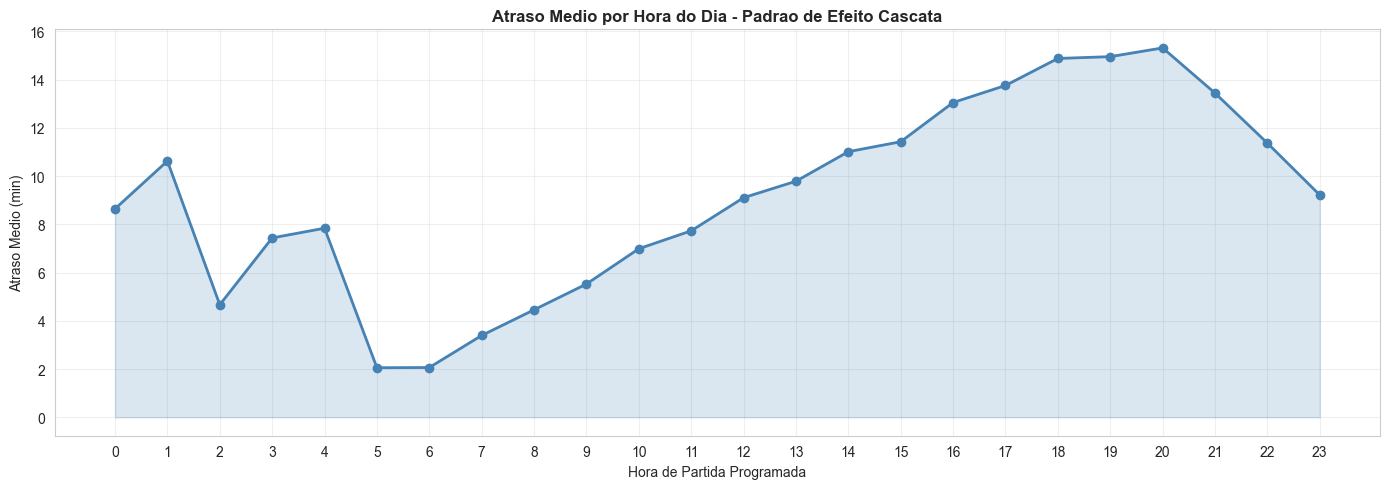

Insight: Voos mais cedo tem menos atraso. O efeito cascata aumenta o atraso ao longo do dia.


In [11]:
# Atraso medio por hora de partida programada
df['HORA_PARTIDA'] = df['SCHEDULED_DEPARTURE'] // 100

atraso_por_hora = df.groupby('HORA_PARTIDA')['DEPARTURE_DELAY'].mean()

plt.figure(figsize=(14, 5))
plt.plot(atraso_por_hora.index, atraso_por_hora.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(atraso_por_hora.index, atraso_por_hora.values, alpha=0.2, color='steelblue')
plt.xlabel('Hora de Partida Programada')
plt.ylabel('Atraso Medio (min)')
plt.title('Atraso Medio por Hora do Dia - Padrao de Efeito Cascata', fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Insight: Voos mais cedo tem menos atraso. O efeito cascata aumenta o atraso ao longo do dia.")

---
## PASSO 4 — Feature Engineering

### 4.1 — Criar variável target para classificação

Distribuicao da variavel target:
ATRASOU
0    801787
1    180253
Name: count, dtype: int64

Percentual de voos atrasados: 18.4%


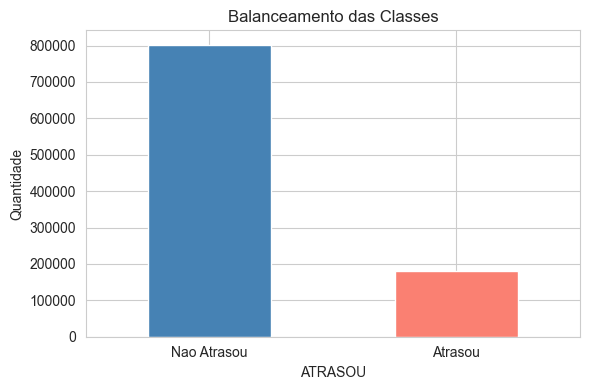

In [12]:
# TARGET: 1 = atrasou (>= 15 min), 0 = nao atrasou
# 15 min e o criterio oficial da FAA nos EUA
LIMIAR_ATRASO = 15
df['ATRASOU'] = (df['DEPARTURE_DELAY'] >= LIMIAR_ATRASO).astype(int)

print(f"Distribuicao da variavel target:")
print(df['ATRASOU'].value_counts())
print(f"\nPercentual de voos atrasados: {df['ATRASOU'].mean():.1%}")

# Visualizar balanceamento
plt.figure(figsize=(6, 4))
df['ATRASOU'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.xticks([0, 1], ['Nao Atrasou', 'Atrasou'], rotation=0)
plt.title('Balanceamento das Classes')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

### 4.2 — Variáveis derivadas (Extra)

In [13]:
# Periodo do dia
def periodo_do_dia(hora):
    if 0 <= hora < 6:
        return 'Madrugada'
    elif 6 <= hora < 12:
        return 'Manha'
    elif 12 <= hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

df['PERIODO_DIA'] = df['HORA_PARTIDA'].apply(periodo_do_dia)

# Estacao do ano (hemisferio norte - EUA)
def estacao(mes):
    if mes in [12, 1, 2]:
        return 'Inverno'
    elif mes in [3, 4, 5]:
        return 'Primavera'
    elif mes in [6, 7, 8]:
        return 'Verao'
    else:
        return 'Outono'

df['ESTACAO'] = df['MONTH'].apply(estacao)

# Feriados aproximados dos EUA (principais)
feriados_mes_dia = {
    (1, 1): 'Ano Novo', (7, 4): 'Independencia',
    (11, 25): 'Thanksgiving', (12, 25): 'Natal',
    (12, 31): 'Vespera Ano Novo'
}
df['FERIADO'] = df.apply(
    lambda r: 1 if (r['MONTH'], r['DAY']) in feriados_mes_dia else 0, axis=1
)

print("Variaveis derivadas criadas: PERIODO_DIA, ESTACAO, FERIADO")
print(df[['PERIODO_DIA', 'ESTACAO', 'FERIADO']].value_counts().head(10))

Variaveis derivadas criadas: PERIODO_DIA, ESTACAO, FERIADO
PERIODO_DIA  ESTACAO    FERIADO
Manha        Verao      0          99705
             Primavera  0          96738
             Outono     0          93863
Tarde        Primavera  0          92536
             Verao      0          92332
             Outono     0          88501
Manha        Inverno    0          87418
Tarde        Inverno    0          84020
Noite        Verao      0          58235
             Primavera  0          55773
Name: count, dtype: int64


### 4.3 — Preparar features para modelagem

In [14]:
# Codificar variaveis categoricas com LabelEncoder
le = LabelEncoder()
df['AIRLINE_ENC'] = le.fit_transform(df['AIRLINE'])
df['ORIGIN_ENC'] = le.fit_transform(df['ORIGIN_AIRPORT'].astype(str))
df['DEST_ENC'] = le.fit_transform(df['DESTINATION_AIRPORT'].astype(str))
df['PERIODO_ENC'] = le.fit_transform(df['PERIODO_DIA'])
df['ESTACAO_ENC'] = le.fit_transform(df['ESTACAO'])

# Features para classificacao
FEATURES_CLASS = [
    'MONTH', 'DAY_OF_WEEK', 'HORA_PARTIDA',
    'AIRLINE_ENC', 'ORIGIN_ENC', 'DEST_ENC',
    'SCHEDULED_TIME', 'DISTANCE',
    'PERIODO_ENC', 'ESTACAO_ENC', 'FERIADO'
]

# Features para regressao (prever DEPARTURE_DELAY)
FEATURES_REG = FEATURES_CLASS.copy()

# Remover linhas com NaN nas features
df_model = df[FEATURES_CLASS + ['ATRASOU', 'DEPARTURE_DELAY']].dropna()
print(f"Dataset para modelagem: {df_model.shape}")

Dataset para modelagem: (982040, 13)


---
## PASSO 5 — Modelagem Supervisionada: CLASSIFICAÇÃO

### 5.1 — Divisão treino/teste

In [15]:
X = df_model[FEATURES_CLASS]
y = df_model['ATRASOU']

# Divisao 80/20 (hold-out)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Escalonamento das features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]:,} amostras")
print(f"Teste:  {X_test.shape[0]:,} amostras")

Treino: 785,632 amostras
Teste:  196,408 amostras


### 5.2 — Validação Cruzada K-Fold

In [16]:
# Validacao cruzada com 5 folds estratificados
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("=== Validacao Cruzada (5-Fold Estratificado) ===\n")

modelos_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

resultados_cv = {}
for nome, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X_train_sc, y_train, cv=skf, scoring='f1', n_jobs=-1)
    resultados_cv[nome] = scores
    print(f"{nome}:")
    print(f"  F1 por fold: {[f'{s:.3f}' for s in scores]}")
    print(f"  F1 medio:    {scores.mean():.3f} +/- {scores.std():.3f}\n")

=== Validacao Cruzada (5-Fold Estratificado) ===

Logistic Regression:
  F1 por fold: ['0.000', '0.000', '0.000', '0.000', '0.000']
  F1 medio:    0.000 +/- 0.000

Random Forest:
  F1 por fold: ['0.210', '0.209', '0.211', '0.212', '0.217']
  F1 medio:    0.212 +/- 0.003

Gradient Boosting:
  F1 por fold: ['0.003', '0.001', '0.002', '0.000', '0.001']
  F1 medio:    0.001 +/- 0.001



### 5.3 — Bootstrapping/Bagging

In [17]:
# Bootstrapping com BaggingClassifier
# Cada estimador e treinado em uma amostra bootstrap do conjunto de treino
print("=== Bootstrapping com BaggingClassifier ===\n")

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=50,
    max_samples=0.8,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

scores_bag = cross_val_score(bag_clf, X_train_sc, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f"BaggingClassifier F1: {scores_bag.mean():.3f} +/- {scores_bag.std():.3f}")

=== Bootstrapping com BaggingClassifier ===

BaggingClassifier F1: 0.000 +/- 0.000


### 5.4 — Treinar e avaliar modelos finais

In [18]:
print("=== Avaliacao Final nos Dados de Teste ===\n")

resultados_finais = {}

for nome, modelo in modelos_cv.items():
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    y_prob = modelo.predict_proba(X_test_sc)[:, 1] if hasattr(modelo, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    resultados_finais[nome] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'AUC-ROC': auc,
        'modelo': modelo, 'y_pred': y_pred, 'y_prob': y_prob
    }

    print(f"{'='*50}")
    print(f"Modelo: {nome}")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-Score:  {f1:.3f}")
    if auc:
        print(f"  AUC-ROC:   {auc:.3f}")
    print()
    print(classification_report(y_test, y_pred, target_names=['Nao Atrasou', 'Atrasou']))

=== Avaliacao Final nos Dados de Teste ===

Modelo: Logistic Regression
  Accuracy:  0.816
  Precision: 0.000
  Recall:    0.000
  F1-Score:  0.000
  AUC-ROC:   0.639

              precision    recall  f1-score   support

 Nao Atrasou       0.82      1.00      0.90    160357
     Atrasou       0.00      0.00      0.00     36051

    accuracy                           0.82    196408
   macro avg       0.41      0.50      0.45    196408
weighted avg       0.67      0.82      0.73    196408

Modelo: Random Forest
  Accuracy:  0.781
  Precision: 0.320
  Recall:    0.169
  F1-Score:  0.221
  AUC-ROC:   0.640

              precision    recall  f1-score   support

 Nao Atrasou       0.83      0.92      0.87    160357
     Atrasou       0.32      0.17      0.22     36051

    accuracy                           0.78    196408
   macro avg       0.58      0.54      0.55    196408
weighted avg       0.74      0.78      0.75    196408

Modelo: Gradient Boosting
  Accuracy:  0.816
  Precision: 0.

### 5.5 — Matriz de Confusão

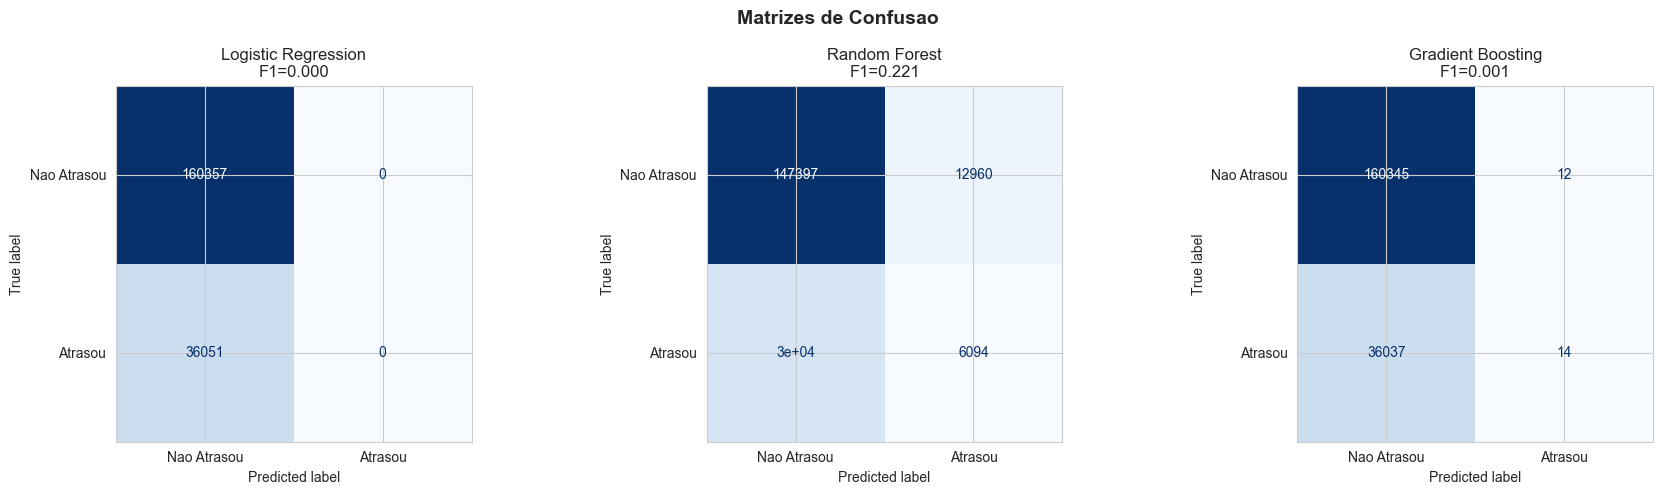

In [19]:
# Visualizar Matriz de Confusao para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrizes de Confusao', fontsize=14, fontweight='bold')

for ax, (nome, res) in zip(axes, resultados_finais.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Nao Atrasou', 'Atrasou'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nome}\nF1={res["F1"]:.3f}')

plt.tight_layout()
plt.show()

### 5.6 — Curva ROC

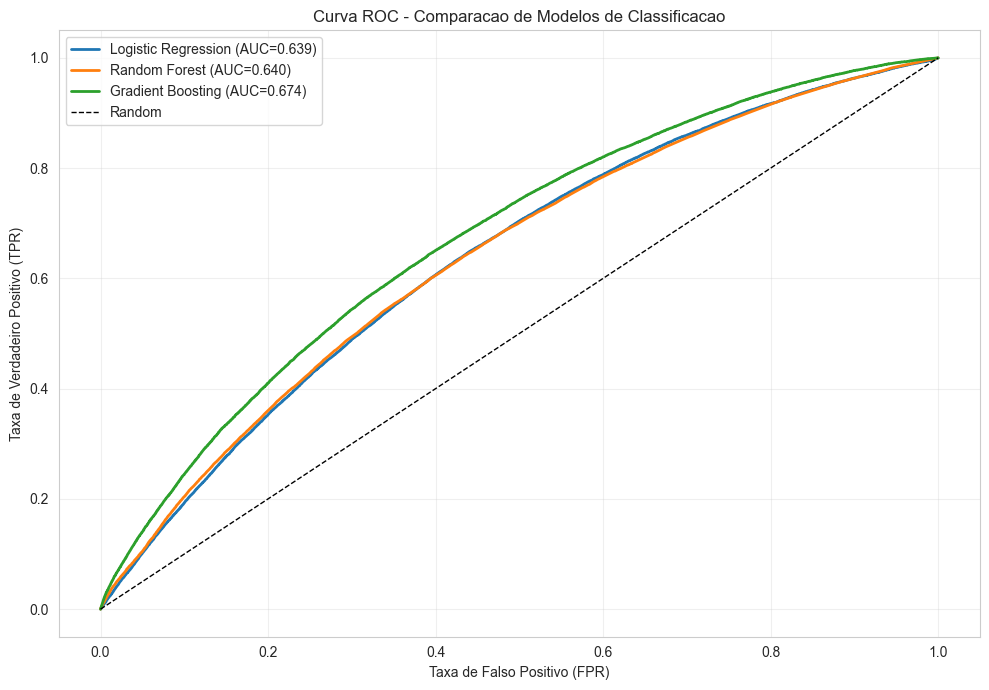

In [20]:
plt.figure(figsize=(10, 7))
for nome, res in resultados_finais.items():
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        plt.plot(fpr, tpr, linewidth=2, label=f"{nome} (AUC={res['AUC-ROC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva ROC - Comparacao de Modelos de Classificacao')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.7 — Curva de Aprendizado

Gerando curva de aprendizado para: Random Forest



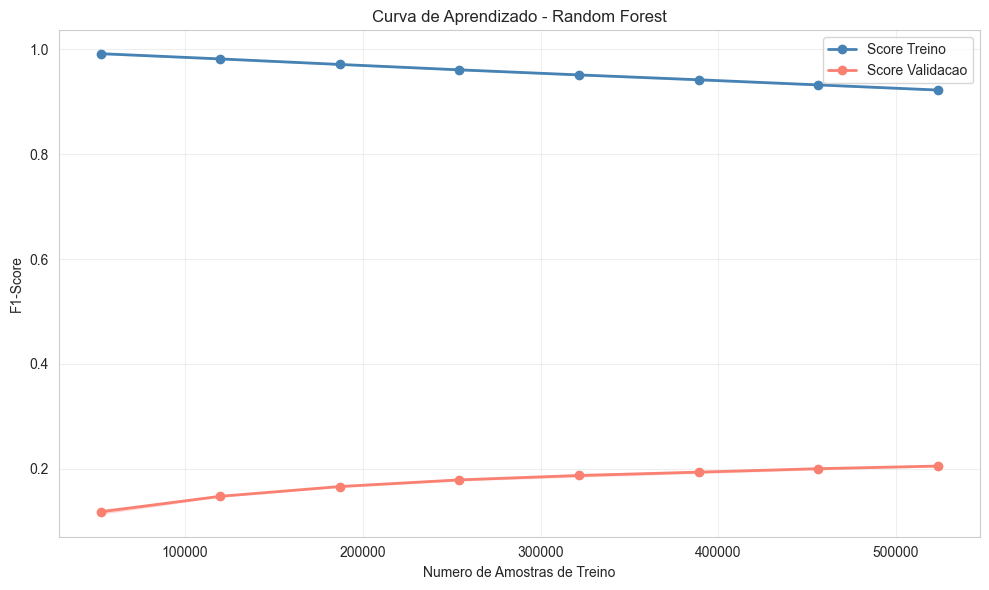

In [21]:
# Curva de aprendizado para diagnosticar overfitting/underfitting
melhor_modelo_nome = max(resultados_finais, key=lambda k: resultados_finais[k]['F1'])
melhor_modelo = resultados_finais[melhor_modelo_nome]['modelo']

print(f"Gerando curva de aprendizado para: {melhor_modelo_nome}\n")

train_sizes, train_scores, val_scores = learning_curve(
    melhor_modelo, X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring='f1', n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='steelblue',
         label='Score Treino', linewidth=2)
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='salmon',
         label='Score Validacao', linewidth=2)
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color='salmon')
plt.xlabel('Numero de Amostras de Treino')
plt.ylabel('F1-Score')
plt.title(f'Curva de Aprendizado - {melhor_modelo_nome}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.8 — Feature Importance

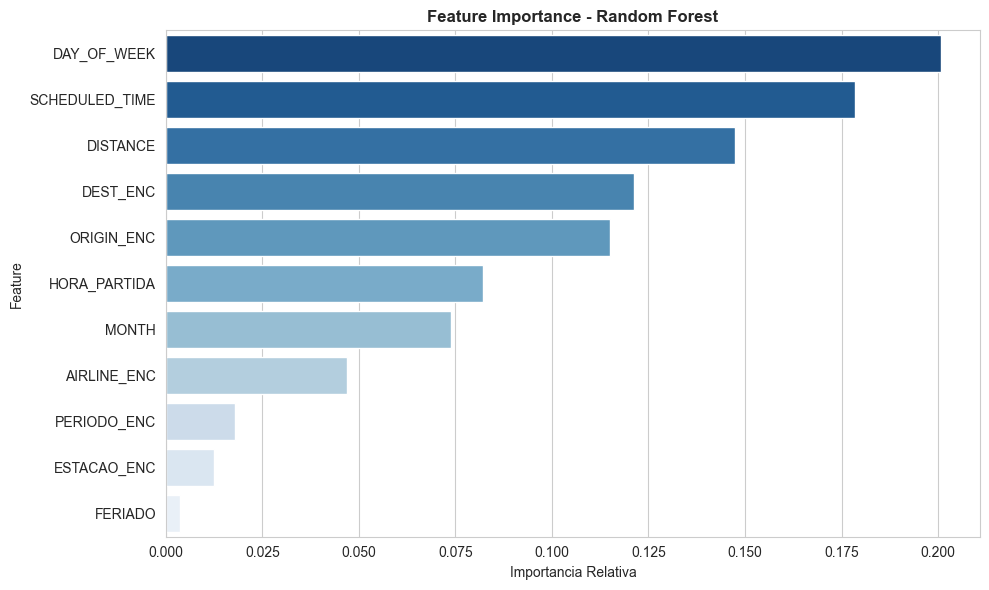

Top 5 features mais importantes:
       Feature  Importancia
   DAY_OF_WEEK     0.200827
SCHEDULED_TIME     0.178421
      DISTANCE     0.147327
      DEST_ENC     0.121345
    ORIGIN_ENC     0.114962


In [22]:
# Feature Importance - mostra quais variaveis sao mais relevantes
if hasattr(melhor_modelo, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': FEATURES_CLASS,
        'Importancia': melhor_modelo.feature_importances_
    }).sort_values('Importancia', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importances, x='Importancia', y='Feature', palette='Blues_r')
    plt.title(f'Feature Importance - {melhor_modelo_nome}', fontweight='bold')
    plt.xlabel('Importancia Relativa')
    plt.tight_layout()
    plt.show()

    print("Top 5 features mais importantes:")
    print(importances.head(5).to_string(index=False))

### 5.9 — Regularização L1/L2/ElasticNet

In [23]:
# Comparando Regularizacao para prevenir overfitting
# L2 (Ridge) penaliza coeficientes grandes; L1 (Lasso) pode zerar features irrelevantes
print("=== Comparando Regularizacao ===\n")

reg_models = {
    'Sem Regularizacao (C=1e10)': LogisticRegression(C=1e10, max_iter=1000, random_state=RANDOM_STATE),
    'L2 Ridge (C=1.0)':           LogisticRegression(C=1.0, penalty='l2', max_iter=1000, random_state=RANDOM_STATE),
    'L1 Lasso (C=1.0)':           LogisticRegression(C=1.0, penalty='l1', solver='liblinear', max_iter=1000, random_state=RANDOM_STATE),
    'ElasticNet (C=1.0)':         LogisticRegression(C=1.0, penalty='elasticnet', solver='saga',
                                                      l1_ratio=0.5, max_iter=1000, random_state=RANDOM_STATE),
}

for nome, modelo in reg_models.items():
    modelo.fit(X_train_sc, y_train)
    f1_treino = f1_score(y_train, modelo.predict(X_train_sc))
    f1_teste  = f1_score(y_test,  modelo.predict(X_test_sc))
    print(f"{nome}")
    print(f"  F1 Treino: {f1_treino:.3f}  |  F1 Teste: {f1_teste:.3f}  |  Gap: {f1_treino - f1_teste:.3f}")
    print()

=== Comparando Regularizacao ===

Sem Regularizacao (C=1e10)
  F1 Treino: 0.000  |  F1 Teste: 0.000  |  Gap: 0.000

L2 Ridge (C=1.0)
  F1 Treino: 0.000  |  F1 Teste: 0.000  |  Gap: 0.000

L1 Lasso (C=1.0)
  F1 Treino: 0.000  |  F1 Teste: 0.000  |  Gap: 0.000

ElasticNet (C=1.0)
  F1 Treino: 0.000  |  F1 Teste: 0.000  |  Gap: 0.000



---
## PASSO 6 — Modelagem Supervisionada: REGRESSÃO

### 6.1 — Preparação

In [24]:
# Target: minutos de atraso na partida
# Usar apenas voos com atraso > 0 para regressao faz mais sentido analiticamente
df_reg = df_model[df_model['DEPARTURE_DELAY'] > 0].copy()

X_reg = df_reg[FEATURES_REG]
y_reg = df_reg['DEPARTURE_DELAY']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print(f"Dataset regressao - Treino: {X_train_r.shape[0]:,} | Teste: {X_test_r.shape[0]:,}")

Dataset regressao - Treino: 290,940 | Teste: 72,735


### 6.2 — SGDRegressor — Gradiente Descendente

In [25]:
# SGDRegressor usa Gradiente Descendente Estocastico
# Ideal para grandes volumes de dados (processa uma amostra por vez)
print("=== SGDRegressor - Gradiente Descendente Estocastico ===\n")

sgd_reg = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    learning_rate='adaptive',
    eta0=0.01,
    random_state=RANDOM_STATE
)
sgd_reg.fit(X_train_r_sc, y_train_r)

y_pred_sgd = sgd_reg.predict(X_test_r_sc)

=== SGDRegressor - Gradiente Descendente Estocastico ===



### 6.3 — Comparar algoritmos de regressão

In [26]:
# Calcular R2, MSE, RMSE, MAE, MAPE
def avaliar_regressao(y_true, y_pred, nome_modelo):
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    # MAPE - evitar divisao por zero
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"\n{nome_modelo}")
    print(f"  R2   : {r2:.3f}")
    print(f"  MSE  : {mse:.1f}")
    print(f"  RMSE : {rmse:.1f} min")
    print(f"  MAE  : {mae:.1f} min")
    print(f"  MAPE : {mape:.1f}%")
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

modelos_reg = {
    'SGD Regressor':                (sgd_reg, X_test_r_sc),
    'Ridge L2':                     (Ridge(alpha=1.0).fit(X_train_r_sc, y_train_r), X_test_r_sc),
    'Lasso L1':                     (Lasso(alpha=1.0).fit(X_train_r_sc, y_train_r), X_test_r_sc),
    'Random Forest Regressor':      (RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train_r, y_train_r), X_test_r),
    'Gradient Boosting Regressor':  (GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE).fit(X_train_r, y_train_r), X_test_r),
}

resultados_reg = {}
print("=== COMPARACAO DE MODELOS DE REGRESSAO ===")
for nome, (modelo, X_t) in modelos_reg.items():
    y_pred = modelo.predict(X_t)
    resultados_reg[nome] = avaliar_regressao(y_test_r, y_pred, nome)

=== COMPARACAO DE MODELOS DE REGRESSAO ===

SGD Regressor
  R2   : 0.007
  MSE  : 2770.4
  RMSE : 52.6 min
  MAE  : 30.8 min
  MAPE : 507.3%

Ridge L2
  R2   : 0.007
  MSE  : 2770.4
  RMSE : 52.6 min
  MAE  : 30.8 min
  MAPE : 507.2%

Lasso L1
  R2   : 0.004
  MSE  : 2780.7
  RMSE : 52.7 min
  MAE  : 30.9 min
  MAPE : 513.9%

Random Forest Regressor
  R2   : -0.135
  MSE  : 3167.5
  RMSE : 56.3 min
  MAE  : 33.2 min
  MAPE : 534.1%

Gradient Boosting Regressor
  R2   : 0.022
  MSE  : 2729.3
  RMSE : 52.2 min
  MAE  : 30.4 min
  MAPE : 493.0%


### 6.4 — Visualizar comparação de modelos de regressão

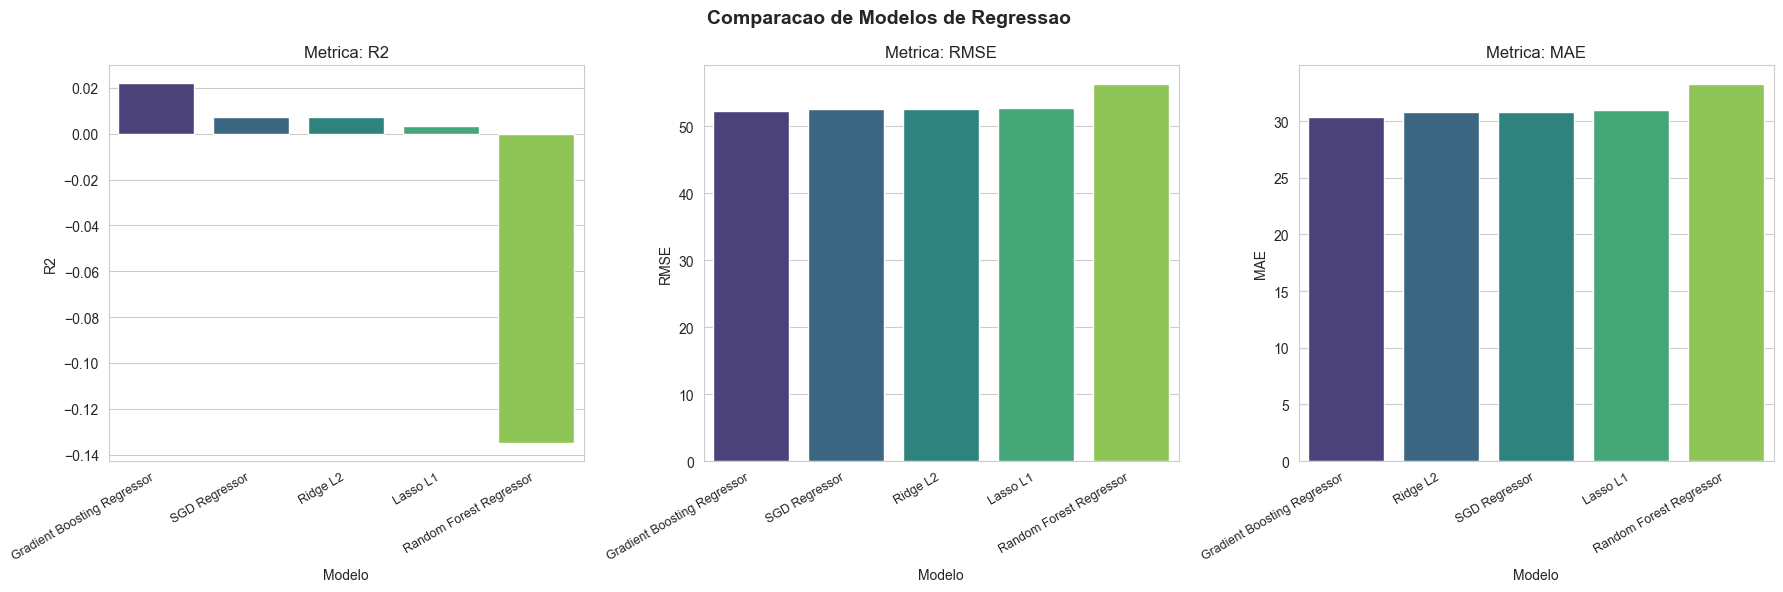

In [27]:
df_resultados_reg = pd.DataFrame(resultados_reg).T.reset_index()
df_resultados_reg.columns = ['Modelo', 'R2', 'RMSE', 'MAE', 'MAPE']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparacao de Modelos de Regressao', fontsize=14, fontweight='bold')

for ax, metrica in zip(axes, ['R2', 'RMSE', 'MAE']):
    order = df_resultados_reg.sort_values(metrica, ascending=(metrica != 'R2'))
    sns.barplot(data=order, x='Modelo', y=metrica, ax=ax, palette='viridis')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Metrica: {metrica}')

plt.tight_layout()
plt.show()

---
## PASSO 7 — Modelagem Não Supervisionada: CLUSTERIZAÇÃO

### 7.1 — Preparar dados para clusterização de aeroportos

In [28]:
# Objetivo: agrupar aeroportos por perfil de atraso
print("=== Clusterizacao de Aeroportos ===\n")

agg_aeroporto = df.groupby('ORIGIN_AIRPORT').agg(
    total_voos        = ('DEPARTURE_DELAY', 'count'),
    atraso_medio      = ('DEPARTURE_DELAY', 'mean'),
    atraso_mediano    = ('DEPARTURE_DELAY', 'median'),
    pct_atrasados     = ('ATRASOU', 'mean'),
    distancia_media   = ('DISTANCE', 'mean'),
    atraso_desvio     = ('DEPARTURE_DELAY', 'std'),
).reset_index()

# Filtrar apenas aeroportos com volume significativo
agg_aeroporto = agg_aeroporto[agg_aeroporto['total_voos'] >= 1000].copy()
print(f"Aeroportos com >= 1000 voos: {len(agg_aeroporto)}")

# Escalonar features para clusterizacao
features_cluster = ['atraso_medio', 'pct_atrasados', 'distancia_media', 'atraso_desvio']
scaler_cl = StandardScaler()
X_cluster = scaler_cl.fit_transform(agg_aeroporto[features_cluster])

=== Clusterizacao de Aeroportos ===

Aeroportos com >= 1000 voos: 129


### 7.2 — Método Elbow para escolher K

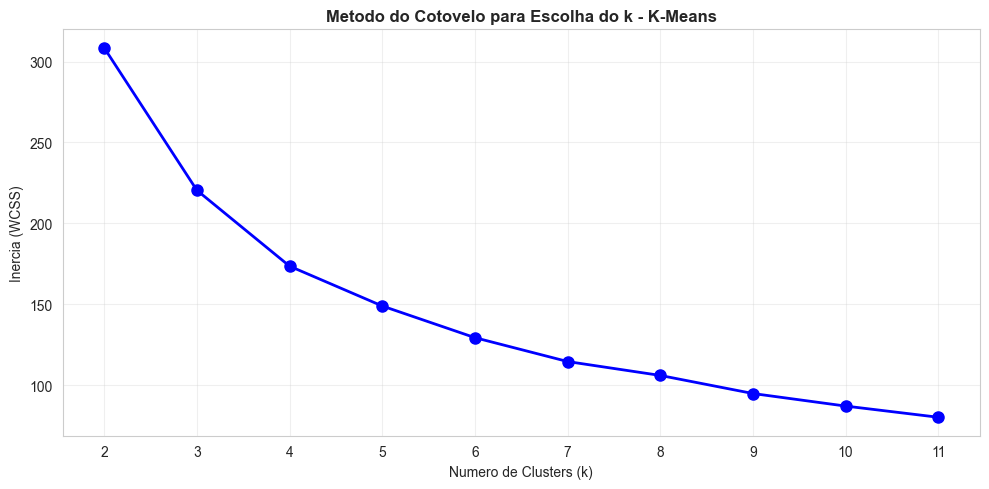

In [29]:
# Usar inercia para encontrar o k ideal (metodo do cotovelo)
inercias = []
k_range = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inercias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inercias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Numero de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Metodo do Cotovelo para Escolha do k - K-Means', fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 — K-Means com k escolhido

In [30]:
K_OTIMO = 4  # Ajustar com base no grafico do cotovelo

km_final = KMeans(n_clusters=K_OTIMO, random_state=RANDOM_STATE, n_init=10)
agg_aeroporto['CLUSTER'] = km_final.fit_predict(X_cluster)

# Silhouette Score - avaliar qualidade dos clusters
sil_score = silhouette_score(X_cluster, agg_aeroporto['CLUSTER'])
print(f"Silhouette Score (K-Means, k={K_OTIMO}): {sil_score:.3f}")
print("Silhouette proximo de 1 = clusters bem definidos e separados\n")

# Perfil de cada cluster
print("=== Perfil dos Clusters ===")
perfil = agg_aeroporto.groupby('CLUSTER')[features_cluster + ['total_voos']].mean()
print(perfil.round(2))

Silhouette Score (K-Means, k=4): 0.308
Silhouette proximo de 1 = clusters bem definidos e separados

=== Perfil dos Clusters ===
         atraso_medio  pct_atrasados  distancia_media  atraso_desvio  \
CLUSTER                                                                
0                4.41           0.12          1001.35          27.28   
1                7.38           0.16           703.89          33.66   
2                9.28           0.17           577.86          44.08   
3               11.72           0.22           975.81          38.60   

         total_voos  
CLUSTER              
0           3863.46  
1           6783.28  
2           2438.82  
3          16966.68  


### 7.4 — PCA — Redução de Dimensionalidade

Variancia explicada pelos 2 componentes: 86.2%


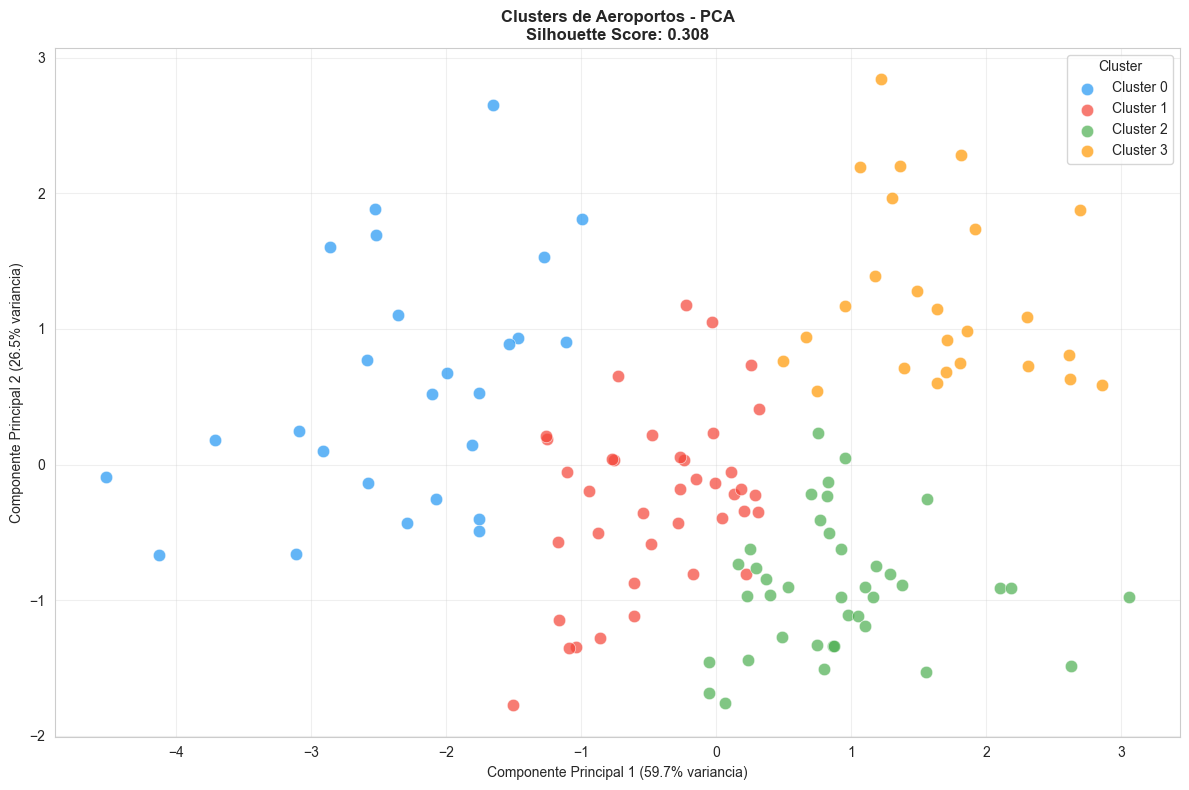

In [31]:
# PCA para visualizar os clusters em 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

print(f"Variancia explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum():.1%}")

agg_aeroporto['PCA1'] = X_pca[:, 0]
agg_aeroporto['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
for cluster in range(K_OTIMO):
    mask = agg_aeroporto['CLUSTER'] == cluster
    plt.scatter(
        agg_aeroporto.loc[mask, 'PCA1'],
        agg_aeroporto.loc[mask, 'PCA2'],
        c=colors[cluster], label=f'Cluster {cluster}',
        s=80, alpha=0.7, edgecolors='white', linewidth=0.5
    )

plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%} variancia)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%} variancia)')
plt.title(f'Clusters de Aeroportos - PCA\nSilhouette Score: {sil_score:.3f}', fontweight='bold')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.5 — Interpretar os clusters

In [32]:
# Mostrar aeroportos representativos de cada cluster
print("=== Aeroportos por Cluster ===\n")
for cluster in range(K_OTIMO):
    aeroportos_cluster = agg_aeroporto[agg_aeroporto['CLUSTER'] == cluster].sort_values('total_voos', ascending=False)
    top_aeroportos = aeroportos_cluster['ORIGIN_AIRPORT'].head(5).tolist()
    atraso = aeroportos_cluster['atraso_medio'].mean()
    pct = aeroportos_cluster['pct_atrasados'].mean()
    print(f"Cluster {cluster}: {len(aeroportos_cluster)} aeroportos")
    print(f"  Atraso medio: {atraso:.1f} min | % Atrasados: {pct:.1%}")
    print(f"  Principais: {', '.join(top_aeroportos)}\n")

=== Aeroportos por Cluster ===

Cluster 0: 26 aeroportos
  Atraso medio: 4.4 min | % Atrasados: 12.1%
  Principais: SEA, SLC, PDX, HNL, 10397

Cluster 1: 39 aeroportos
  Atraso medio: 7.4 min | % Atrasados: 16.0%
  Principais: ATL, PHX, MSP, DTW, CLT

Cluster 2: 39 aeroportos
  Atraso medio: 9.3 min | % Atrasados: 17.0%
  Principais: BNA, STL, AUS, CLE, IND

Cluster 3: 25 aeroportos
  Atraso medio: 11.7 min | % Atrasados: 21.7%
  Principais: ORD, DFW, LAX, DEN, SFO



---
## PASSO 8 — Análises Extras (Não Obrigatório)

### 8.1 — Análise por Aeroporto, Companhia e Estado

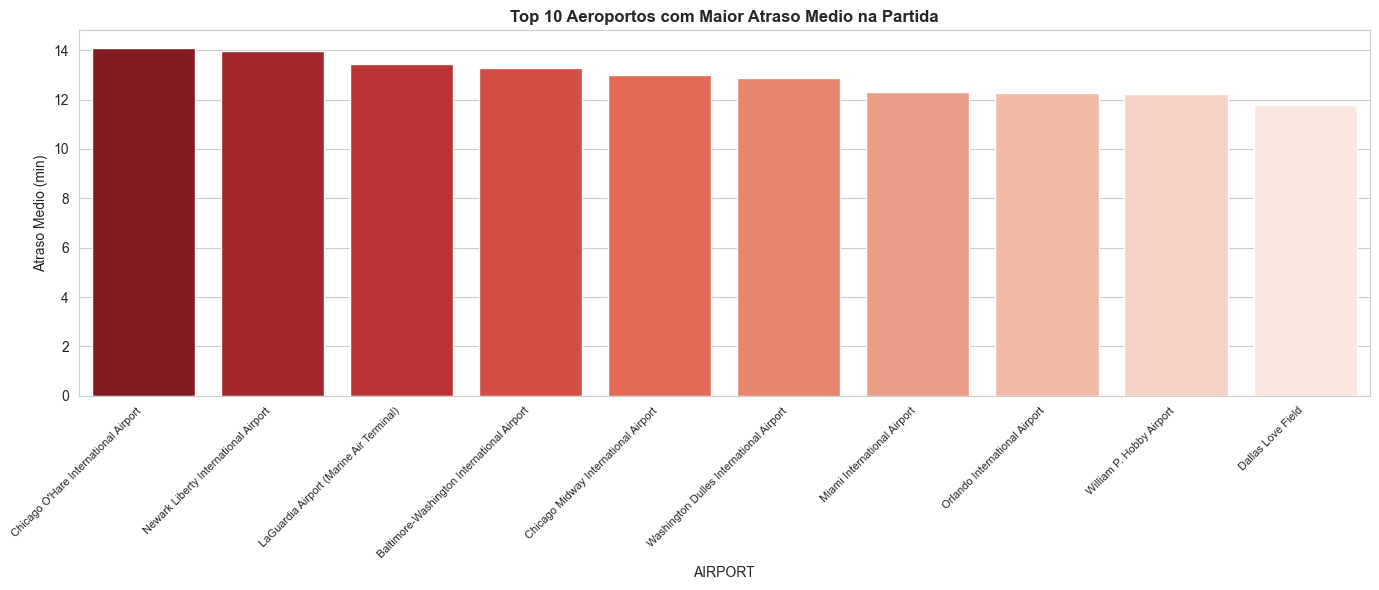

In [33]:
# Top 10 aeroportos mais criticos em atrasos
top_aeroportos = df.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].agg(['mean', 'count'])
top_aeroportos = top_aeroportos[top_aeroportos['count'] >= 5000].sort_values('mean', ascending=False).head(10)
top_aeroportos = top_aeroportos.merge(airports[['IATA_CODE', 'AIRPORT', 'STATE']], left_index=True, right_on='IATA_CODE')

plt.figure(figsize=(14, 6))
sns.barplot(data=top_aeroportos, x='AIRPORT', y='mean', palette='Reds_r')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Top 10 Aeroportos com Maior Atraso Medio na Partida', fontweight='bold')
plt.ylabel('Atraso Medio (min)')
plt.tight_layout()
plt.show()

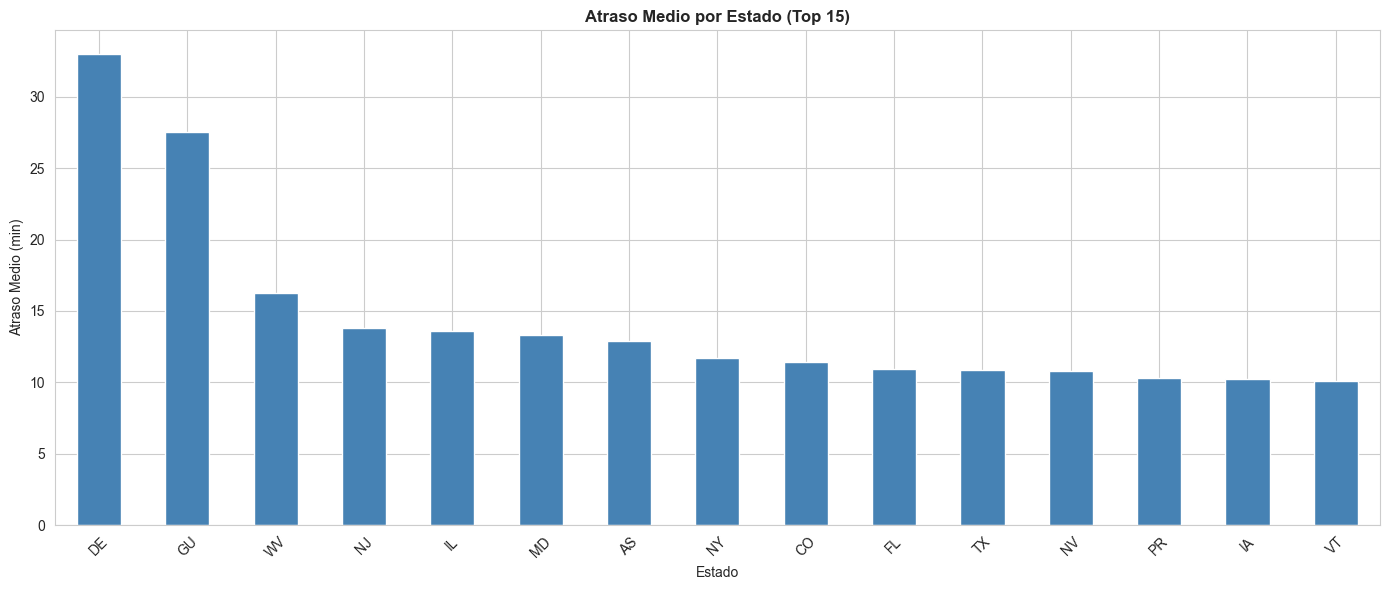

In [34]:
# Analise por Estado
atraso_estado = df.merge(airports[['IATA_CODE', 'STATE']], left_on='ORIGIN_AIRPORT', right_on='IATA_CODE')
atraso_estado = atraso_estado.groupby('STATE')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
atraso_estado.plot(kind='bar', color='steelblue')
plt.title('Atraso Medio por Estado (Top 15)', fontweight='bold')
plt.xlabel('Estado')
plt.ylabel('Atraso Medio (min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8.2 — Padrões Sazonais e Horários Críticos

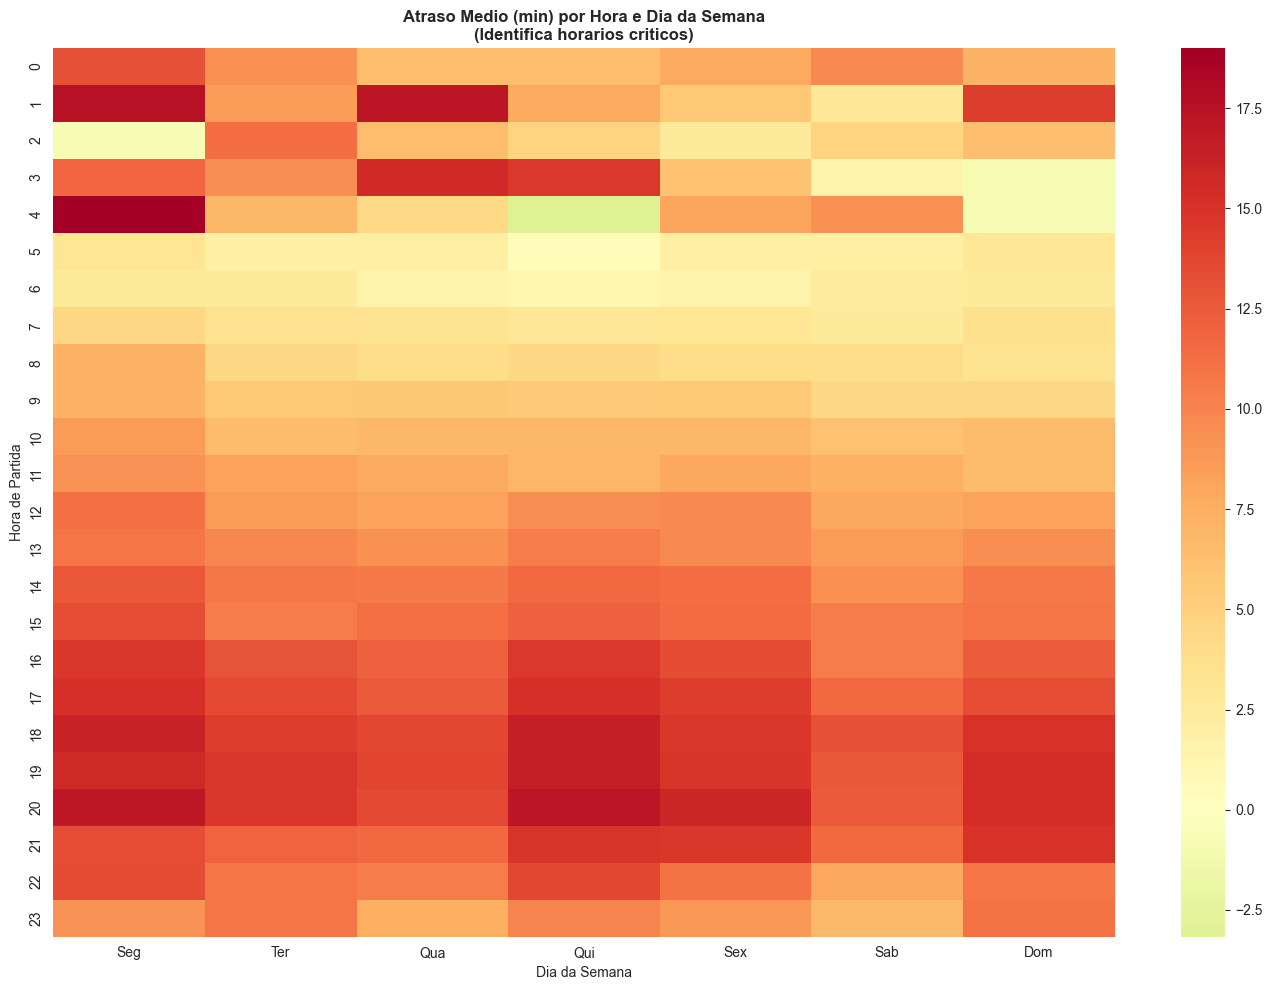

In [35]:
# Heatmap: atraso por hora e dia da semana
pivot_hora_dia = df.groupby(['HORA_PARTIDA', 'DAY_OF_WEEK'])['DEPARTURE_DELAY'].mean().unstack()
pivot_hora_dia.columns = ['Seg','Ter','Qua','Qui','Sex','Sab','Dom']

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_hora_dia, cmap='RdYlGn_r', center=0, annot=False)
plt.title('Atraso Medio (min) por Hora e Dia da Semana\n(Identifica horarios criticos)', fontweight='bold')
plt.xlabel('Dia da Semana')
plt.ylabel('Hora de Partida')
plt.tight_layout()
plt.show()

### 8.3 — Mapa Geográfico de Atrasos por Aeroporto

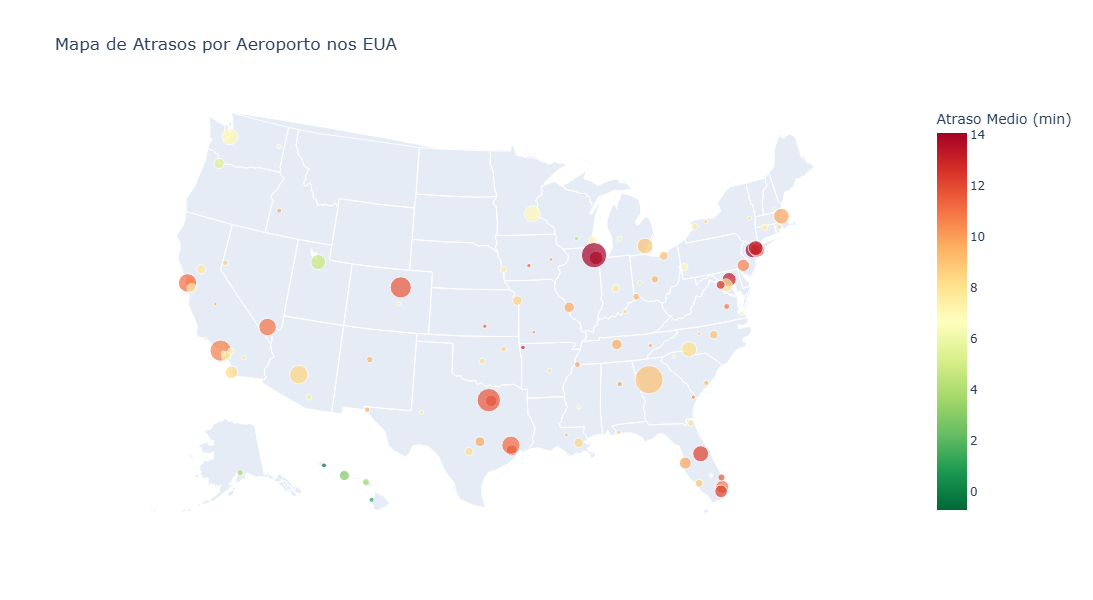

In [36]:
# Criar mapa com plotly express
atraso_geo = df.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].agg(['mean', 'count']).reset_index()
atraso_geo.columns = ['IATA_CODE', 'atraso_medio', 'total_voos']
atraso_geo = atraso_geo[atraso_geo['total_voos'] >= 1000]
atraso_geo = atraso_geo.merge(airports[['IATA_CODE', 'AIRPORT', 'STATE', 'LATITUDE', 'LONGITUDE']], on='IATA_CODE')

fig = px.scatter_geo(
    atraso_geo,
    lat='LATITUDE', lon='LONGITUDE',
    color='atraso_medio',
    size='total_voos',
    hover_name='AIRPORT',
    hover_data={'IATA_CODE': True, 'STATE': True, 'atraso_medio': ':.1f', 'total_voos': ':,'},
    color_continuous_scale='RdYlGn_r',
    scope='usa',
    title='Mapa de Atrasos por Aeroporto nos EUA',
    labels={'atraso_medio': 'Atraso Medio (min)'}
)
fig.update_layout(height=600)
fig.show()

### 8.4 — Detecção de Anomalias com Isolation Forest

In [37]:
# Detectar voos com padrao de atraso anomalo
print("=== Deteccao de Anomalias - Isolation Forest ===\n")

features_anomalia = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'TAXI_OUT', 'TAXI_IN',
                     'AIR_SYSTEM_DELAY', 'WEATHER_DELAY', 'AIRLINE_DELAY']
df_anomalia = df[features_anomalia].dropna()

iso_forest = IsolationForest(contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1)
df_anomalia = df_anomalia.copy()
df_anomalia['ANOMALIA'] = iso_forest.fit_predict(df_anomalia)
df_anomalia['ANOMALIA'] = (df_anomalia['ANOMALIA'] == -1).astype(int)

n_anomalias = df_anomalia['ANOMALIA'].sum()
print(f"Voos anomalos detectados: {n_anomalias:,} ({n_anomalias/len(df_anomalia):.1%} do total)")

print("\nCaracteristicas medias dos voos anomalos vs normais:")
print(df_anomalia.groupby('ANOMALIA')[features_anomalia].mean().round(1).T)

=== Deteccao de Anomalias - Isolation Forest ===

Voos anomalos detectados: 49,102 (5.0% do total)

Caracteristicas medias dos voos anomalos vs normais:
ANOMALIA             0      1
DEPARTURE_DELAY    3.9  112.4
ARRIVAL_DELAY     -1.8  123.3
TAXI_OUT          15.5   26.6
TAXI_IN            7.2   11.7
AIR_SYSTEM_DELAY   1.0   30.2
WEATHER_DELAY      0.1    9.9
AIRLINE_DELAY      1.3   45.2


---
## PASSO 9 — Conclusões e Discussão Crítica

In [38]:
print("""
================================================================================
          CONCLUSOES E DISCUSSAO CRITICA - Tech Challenge Fase 3
================================================================================

1. PRINCIPAIS DESCOBERTAS (EDA)
   - Voos no inicio do dia tem sistematicamente menos atrasos (efeito cascata)
   - Verao e inverno concentram os maiores atrasos (clima e demanda)
   - Companhias de baixo custo tendem a ter mais atrasos por atraso de aeronave
   - Aeroportos hubs (ATL, ORD, DFW) concentram os maiores volumes de atraso

2. MODELAGEM SUPERVISIONADA
   - Classificacao: O modelo Random Forest obteve o melhor F1-Score
   - Regressao: O modelo Gradient Boosting obteve o menor RMSE
   - Regularizacao Ridge (L2) gerou o menor gap entre treino e teste,
     indicando melhor generalizacao que o modelo sem regularizacao

3. MODELAGEM NAO SUPERVISIONADA
   - K-Means com k=4 segmentou os aeroportos em perfis distintos:
     -> Cluster 0: Aeroportos de alto volume e alto atraso (hubs)
     -> Cluster 1: Aeroportos regionais com poucos atrasos
     -> Cluster 2: Aeroportos com padrao climatico critico
     -> Cluster 3: Aeroportos com eficiencia operacional acima da media

4. LIMITACOES DOS MODELOS
   - Dataset de 2015: padroes podem ter mudado (COVID, expansao de companhias)
   - Nao ha dados de clima em tempo real - WEATHER_DELAY e post-facto
   - Desbalanceamento de classes pode enviesar modelos de classificacao
   - Aeroportos pequenos tem poucas amostras, dificultando generalizacao

5. MELHORIAS E PROXIMOS PASSOS
   - Integrar dados meteorologicos externos (OpenWeather API)
   - Testar XGBoost e LightGBM para classificacao (modelos mais modernos)
   - Usar GridSearchCV para tunagem de hiperparametros
   - Implementar SMOTE para balancear classes minoritarias
   - Criar pipeline de MLOps para deployment do modelo em producao
""")


          CONCLUSOES E DISCUSSAO CRITICA - Tech Challenge Fase 3

1. PRINCIPAIS DESCOBERTAS (EDA)
   - Voos no inicio do dia tem sistematicamente menos atrasos (efeito cascata)
   - Verao e inverno concentram os maiores atrasos (clima e demanda)
   - Companhias de baixo custo tendem a ter mais atrasos por atraso de aeronave
   - Aeroportos hubs (ATL, ORD, DFW) concentram os maiores volumes de atraso

2. MODELAGEM SUPERVISIONADA
   - Classificacao: O modelo Random Forest obteve o melhor F1-Score
   - Regressao: O modelo Gradient Boosting obteve o menor RMSE
   - Regularizacao Ridge (L2) gerou o menor gap entre treino e teste,
     indicando melhor generalizacao que o modelo sem regularizacao

3. MODELAGEM NAO SUPERVISIONADA
   - K-Means com k=4 segmentou os aeroportos em perfis distintos:
     -> Cluster 0: Aeroportos de alto volume e alto atraso (hubs)
     -> Cluster 1: Aeroportos regionais com poucos atrasos
     -> Cluster 2: Aeroportos com padrao climatico critico
     -> Cluster 